In [1]:
!pip install tf-levenberg-marquardt 

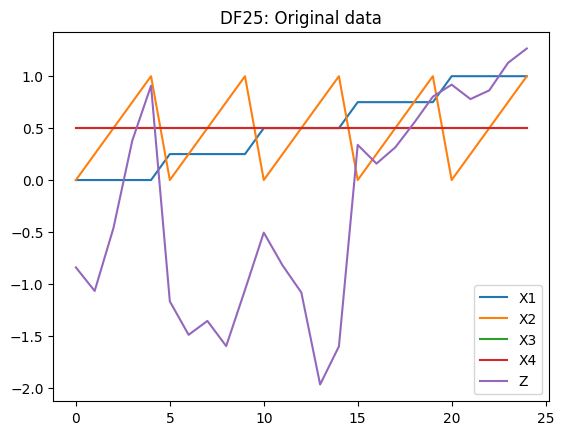

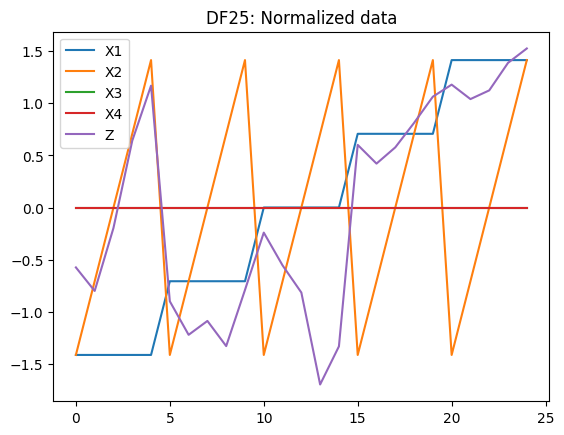

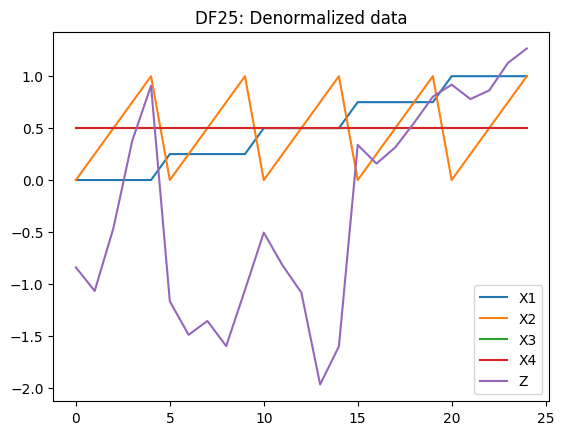

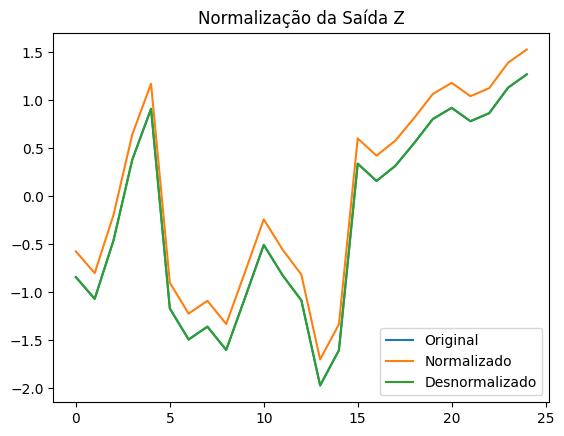

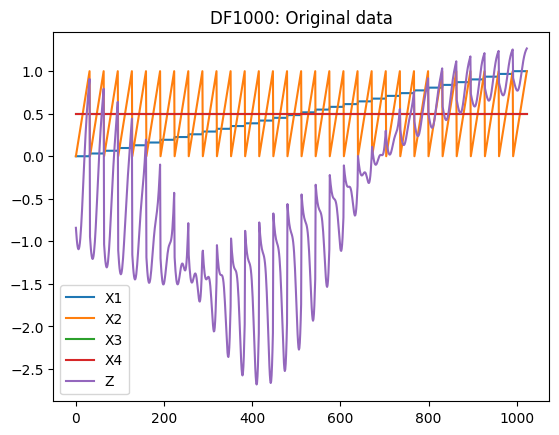

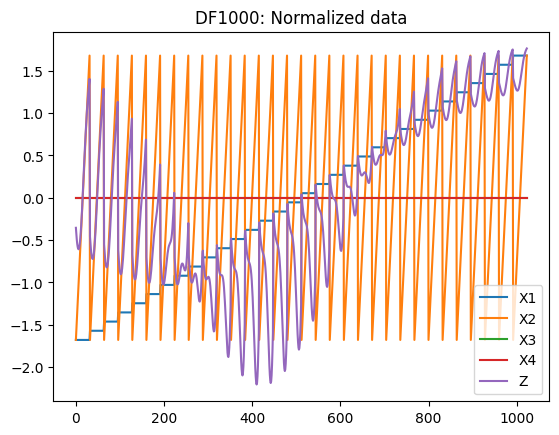

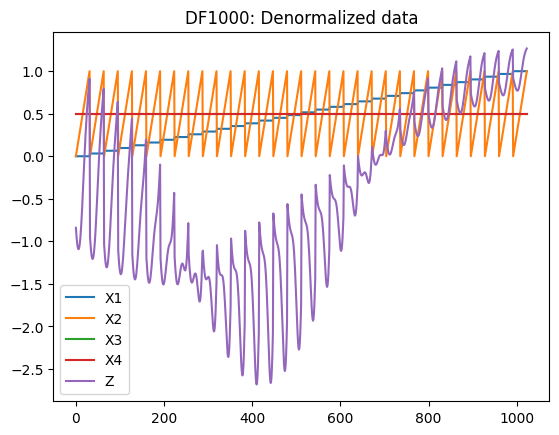

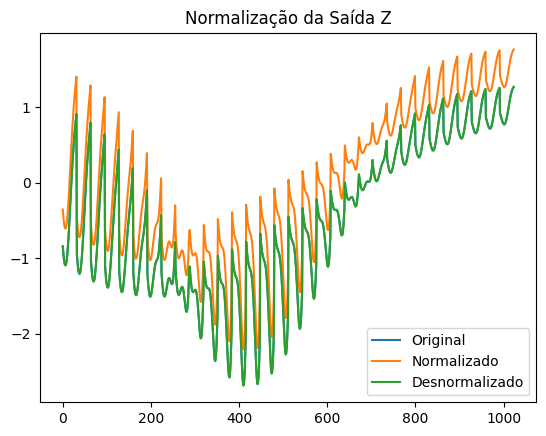

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Escaladores globais
scaler = StandardScaler()
out_scaler = StandardScaler()

# Função Hartmann4
def function(x):
    alpha = np.array([1.0, 1.2, 3.0, 3.2])

    A = np.array([
        [10,   3, 17, 3.5],
        [0.05, 10, 17, 0.1],
        [3, 3.5, 1.7, 10],
        [17,   8, 0.05, 10]
    ])

    P = 1e-4 * np.array([
        [1312, 1696, 5569, 124],
        [2329, 4135, 8307, 3736],
        [2348, 1451, 3522, 2883],
        [4047, 8828, 8732, 5743]
    ])

    x = np.asarray(x)
    if np.any((x < 0) | (x > 1)):
        raise ValueError("Todos os valores de x devem estar no intervalo [0, 1].")

    diff = x - P
    exp_term = np.exp(-np.sum(A * diff**2, axis=1))
    z = (1.1 - np.dot(alpha, exp_term)) / 0.839

    x1, x2, x3, x4 = x
    return z, x1, x2, x3, x4

# Criação do DataFrame com grid 2D (x1, x2), fixando x3, x4
def create_dataframe(grid, x3=0.5, x4=0.5):
    x_vals = np.linspace(0, 1, grid)
    data = []

    for x1 in x_vals:
        for x2 in x_vals:
            z, x1, x2, x3_val, x4_val = function([x1, x2, x3, x4])
            data.append([x1, x2, x3_val, x4_val, z])

    df = pd.DataFrame(data, columns=["X1", "X2", "X3", "X4", "Z"])
    return df

# Visualização da normalização
def show_norm(df, label="function", plot=False):
    df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    df_denorm = pd.DataFrame(scaler.inverse_transform(df_norm), columns=df_norm.columns)

    if plot:
        df.plot(title=f"{label}: Original data")
        df_norm.plot(title=f"{label}: Normalized data")
        df_denorm.plot(title=f"{label}: Denormalized data")
        plt.show()
    return df_norm

# Visualizar normalização da saída Z
def test_out_scaler(df):
    out = df["Z"].values.reshape(-1, 1)
    plt.figure()
    plt.plot(out, label='Original')
    out_scaler.fit(out)
    norm = out_scaler.transform(out)
    plt.plot(norm, label='Normalizado')
    plt.plot(out_scaler.inverse_transform(norm), label='Desnormalizado')
    plt.title("Normalização da Saída Z")
    plt.legend()
    plt.show()

# Execução dos testes
df_25 = create_dataframe(grid=5)
df_25_norm = show_norm(df_25, label="DF25", plot=True)
test_out_scaler(df_25)

df_1000 = create_dataframe(grid=32)
df_1000_norm = show_norm(df_1000, label="DF1000", plot=True)
test_out_scaler(df_1000)




In [3]:
def split_df(df):
    _input = np.vstack([df['X1'], df['X2'], df['X3'], df['X4']]).T
    _output = np.array(df['Z'])
    return (_input, _output)


In [4]:
import tensorflow as tf
import numpy as np
from keras import regularizers
from keras import initializers
import tf_levenberg_marquardt as lm

# layers, neurons
class ShuffleArchitecture:
    def __init__(self, input_size, hidden_sizes, output_size, act_h, act_o, param_reg):
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.act_h = act_h
        self.act_o = act_o
        self.regularizer = regularizers.L2(param_reg)
        self.initializer = initializers.RandomUniform(minval=-0.5, maxval=0.5, seed=np.random.randint(1, 10000))

    def compute_k(self):
        total_parameters = 0
        for layer in self.model.layers:
            weights = layer.get_weights()
            if len(weights) > 0:  
                for w in weights:
                    total_parameters += np.prod(w.shape)
        return total_parameters
        
    def set_architecture(self):
        self.model = tf.keras.Sequential()
        self.model.add(tf.keras.layers.Dense(self.hidden_sizes[0],
                        input_shape=(self.input_size,),
                        activation=self.act_h,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,                        
                        ))  # input layer

        for size in self.hidden_sizes[1:]:  # hidden layers
            self.model.add(tf.keras.layers.Dense(size,
                            activation=self.act_h,
                            kernel_regularizer=self.regularizer,
                            kernel_initializer=self.initializer,  
                        ))

        self.model.add(tf.keras.layers.Dense(self.output_size,
                        activation=self.act_o,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,  
                        ))  # output layer

    def create_model(self, _learning_rate):
        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=_learning_rate),
            loss=tf.keras.losses.MeanSquaredError(),
        )
        self.lm_model = lm.model.ModelWrapper(
            tf.keras.models.clone_model(self.model)
        )
        self.lm_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=_learning_rate),
            loss=lm.loss.MeanSquaredError()
        )
        return self.lm_model


2025-06-24 16:21:57.925714: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-24 16:21:57.993804: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-24 16:21:57.993846: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-24 16:21:57.995456: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-24 16:21:58.004176: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-24 16:21:58.004935: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [5]:
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 

class TrainWithSmallDataset:
    def __init__(self, batch_size=1000):
        self.batch_size = batch_size
        self.betters = []
        self.k = 0

    def create_dataset(self, input, output):
      input = tf.cast(input, tf.float32)  # Mantém shape (N, 4)
      output = tf.expand_dims(tf.cast(output, tf.float32), axis=-1)  # Output vira (N, 1)
      dataset = tf.data.Dataset.from_tensor_slices((input, output))
      dataset = dataset.shuffle(len(input))
      dataset = dataset.batch(self.batch_size).cache()
      dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
      return (dataset, input, output)

    def split_dataset(self, input, output, sup_input, sup_output):
      input_train, input_vt, output_train, output_vt = train_test_split(input, output, test_size=0.3, shuffle = True)
      input_val, input_test, output_val, output_test = train_test_split(input_vt, output_vt, test_size=0.5, shuffle = True)

      self.train_dataset, self.train_input, self.train_output = self.create_dataset(input_train, output_train)
      self.val_dataset, self.val_input, self.val_output = self.create_dataset(input_val, output_val)
      self.test_dataset, self.test_input, self.test_output = self.create_dataset(input_test, output_test)
      self.vt_dataset, self.vt_input, self.vt_output = self.create_dataset(input_vt, output_vt)
      self.sup_dataset, self.sup_input, self.sup_output = self.create_dataset(sup_input, sup_output)
      self.dataset, self.input, self.output = self.create_dataset(input, output)

      self._data = (input, output)
      self._train = (input_train, output_train)
      self._vt = (input_vt, output_vt)
      self._val = (input_val, output_val)
      self._test = (input_test, output_test)
      self._sup = (sup_input, sup_output)
 
    def train_using_lm(self, train_dataset, epochs=1000):
      early_stopping_monitor = EarlyStopping(monitor='val_loss',
                                              patience=6,
                                              restore_best_weights=True)

      self.results = self.lm_model.fit(train_dataset,
                                            epochs=epochs,
                                            validation_data=self.val_dataset,
                                            callbacks=[early_stopping_monitor],
                                            verbose=0)
      print ("Stopped at epoch: ", early_stopping_monitor.stopped_epoch)
    
    def get_new_metrics(self, orig, pred, r2, mse):
      n = len(orig) # N: quantidade de saidas
      k = self.k
      waste = (orig.flatten() - pred.flatten())

      mape = mean_absolute_percentage_error(orig, pred)  
      r2_adj = 1 - (((n - 1)/(n - k - 1)) * (1 - r2))
      rsd = np.sqrt(np.sum(waste ** 2) / (n - 2))
      rmse = root_mean_squared_error(orig, pred)          
      aic = (-2 * np.log(mse)) + (2 * k)
      bic = (-2 * np.log(mse)) + (k * np.log(n))
      return (mape, r2_adj, rsd, rmse, aic, bic)
      

    def get_metrics(self):
          # Calculando a saida com os dados normalizados
          pred = self.lm_model.predict(self.input).flatten()
          test_pred = self.lm_model.predict(self.test_input).flatten()
          val_pred = self.lm_model.predict(self.val_input).flatten()
          vt_pred = self.lm_model.predict(self.vt_input).flatten()
          sup_pred = self.lm_model.predict(self.sup_input).flatten()

          # Calculando as metricas com a saida desnormalizada
          pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
          test_pred_denorm = out_scaler.inverse_transform(test_pred.reshape(-1, 1))
          val_pred_denorm = out_scaler.inverse_transform(val_pred.reshape(-1, 1))
          vt_pred_denorm = out_scaler.inverse_transform(vt_pred.reshape(-1, 1))
          sup_pred_denorm = out_scaler.inverse_transform(sup_pred.reshape(-1, 1))

          out_denorm = out_scaler.inverse_transform(self._data[1].reshape(-1, 1))
          test_denorm = out_scaler.inverse_transform(self._test[1].reshape(-1, 1))
          val_denorm = out_scaler.inverse_transform(self._val[1].reshape(-1, 1))
          vt_denorm = out_scaler.inverse_transform(self._vt[1].reshape(-1, 1))    
          sup_denorm = out_scaler.inverse_transform(self._sup[1].reshape(-1, 1))

          r2 = r2_score(out_denorm, pred_denorm)
          r2_test = r2_score(test_denorm, test_pred_denorm)
          r2_val = r2_score(val_denorm, val_pred_denorm)
          r2_vt = r2_score(vt_denorm,  vt_pred_denorm)
          r2_sup = r2_score(sup_denorm,  sup_pred_denorm)

          mse = mean_squared_error(out_denorm, pred_denorm)
          mse_test = mean_squared_error(test_denorm, test_pred_denorm)
          mse_val = mean_squared_error(val_denorm, val_pred_denorm)
          mse_vt = mean_squared_error(vt_denorm,  vt_pred_denorm)
          mse_sup = mean_squared_error(sup_denorm,  sup_pred_denorm)
          
          mape, r2_adj, rsd, rmse, aic, bic = self.get_new_metrics(out_denorm, pred_denorm, r2, mse)
          metrics = {
                          'r2': r2,
                          'r2_sup': r2_sup,
                          'r2_test': r2_test,
                          'r2_val': r2_val,
                          'r2_vt': r2_vt,
                          'mse': mse,
                          'mse_sup': mse_sup,
                          'mse_test': mse_test,
                          'mse_val': mse_val,
                          'mse_vt': mse_vt,
                          'mape': mape,
                          'rmse': rmse,
                          'r2_adj': r2_adj,
                          'rsd': rsd,
                          'aic': aic,
                          'bic': bic
                          }

          return metrics

In [6]:
import pickle
from itertools import product

class Tester:
  def __init__(self, run_times=500, dataset_run_times=10):
    self.run_times = run_times
    self.better_metrics = {}
    self.dataset_run_times = dataset_run_times
    self.input_25, self.output_25 = split_df(df_25_norm)
    self.input_1000, self.output_1000 = split_df(df_1000_norm)
  
  def setArchitecure(self, trainer, _hidden_sizes, _pg, _lr):
    shuffler = ShuffleArchitecture(input_size=4,
                                    hidden_sizes=_hidden_sizes,
                                    output_size=1,
                                    act_h='tanh',
                                    act_o='linear',
                                    param_reg=_pg)
    shuffler.set_architecture()    
    trainer.lm_model = shuffler.create_model(_lr)
    trainer.k = shuffler.compute_k()

  def Train(self, trainer, epochs=1000):
    trainer.train_using_lm(trainer.train_dataset, epochs=epochs)
    return(trainer.get_metrics(), trainer.lm_model)

  def SaveModelWeights(self, model, fileName):
    path = f"content/models/{fileName}.keras"
    open(path,'w').close()
    model.save_weights(path)

  def SaveDataset(self, trainer, fileName):
    path = f"content/dataset/{fileName}.pkl" 
    with open(path, 'wb') as f:
      pickle.dump((trainer._data, trainer._train, trainer._vt, trainer._val, trainer._test), f)
      
  def LoopWeights(self, sort_by, boundarie, trainer, idx):
    better_model = 0
    save = False

    for i in range(self.run_times):
      print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
      metrics, model = self.Train(trainer)
      if (metrics[sort_by] <= boundarie): # should be >= to acsending metrics
        fileName = f"model_{idx}_{better_model}"
        self.SaveModelWeights(model, fileName)
        self.better_metrics[fileName] = metrics
        better_model += 1
        save = True
    return(save)

  def Loop(self, sort_by, boundarie, hidden_sizes, regularizers, learning_rate):
    trainer = TrainWithSmallDataset()

    for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
      header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
      print(f"Testando combinacao{count}: {header}")
      self.setArchitecure(trainer, hidden_size, reg, lr)
      for j in range(self.dataset_run_times):
        trainer.split_dataset(self.input_25, self.output_25, self.input_1000, self.output_1000)
        if (self.LoopWeights(sort_by, boundarie, trainer, f"{count}_{j}") == True):
          self.SaveDataset(trainer, f"dataset_{count}_{j}")
          self.DisplayBetterResults('mse_sup', header, f"{count}_{j}")
        self.better_metrics = {}

  def DisplayBetterResults(self, sort_by, header, dataset=0):
    df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
    df = df.sort_values([sort_by])
    display(df)
    path = f'content/results/metrics_{dataset}'
    df.to_excel(f"{path}.xlsx", index=True)
    print(f"DataFrame salvo em {path}")
    with open(f"{path}.txt", 'w') as arquivo:
      arquivo.write(header)

# Treinando com 25 dados


In [7]:
tester = Tester(run_times=25, dataset_run_times=10)
tester.Loop(sort_by='mse',
            boundarie = 0.02,
            hidden_sizes = [[3, 2], [4, 2], [3, 3], [4, 4], [5, 5], [7, 3], [3, 4]],
            regularizers=[0.5, 0.03],
            learning_rate=[0.1, 0.05])

Testando combinacao1: Hidden Size=[3, 2], regularizer=0.5, learning_rate=0.1
+++++++++++ [1_0] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 6ms/step
+++++++++++ [1_0] | 2 ++++++++++++++++++
Stopped at epoch:  7
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_0] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 5ms/step
+++++++++++ [1_0] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_0] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_2_1_0,0.980175,0.9289,0.974794,0.943286,0.965813,0.019655,0.070491,0.01487,0.039632,0.027251,0.291273,0.140196,1.237898,0.146165,59.858848,91.54962


DataFrame salvo em content/results/metrics_2_1
+++++++++++ [2_2] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [2_2] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 5ms/step
+++++++++++ [2_2] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 6ms/step
+++++++++++ [2_2] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 7ms/step
+++++++++++ [2_2] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [2_2] | 6 ++++++++++++++++++
Stopped at epoch:  7
32/32 [==============================] - 0s 2ms/step
+++++++++++ [2_2] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [2_2] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [2_2] | 9 +++++++++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_9_3_5,0.980051,0.913094,0.965575,0.778483,0.945429,0.019778,0.086161,0.053414,0.045525,0.049470,0.184597,0.140634,1.068396,0.146621,69.846389,107.631539
model_9_3_4,0.980562,0.912340,0.968906,0.795967,0.950263,0.019271,0.086909,0.048245,0.041932,0.045088,0.194378,0.138820,1.066643,0.144730,69.898297,107.683448
model_9_3_3,0.980908,0.910657,0.971617,0.819133,0.955208,0.018929,0.088578,0.044039,0.037171,0.040605,0.203893,0.137582,1.065460,0.143439,69.934140,107.719290
model_9_3_2,0.981003,0.908149,0.973775,0.846484,0.960155,0.018834,0.091064,0.040691,0.031550,0.036120,0.213284,0.137238,1.065133,0.143080,69.944156,107.729307
model_9_3_1,0.980770,0.904906,0.975532,0.876452,0.965056,0.019065,0.094280,0.037964,0.025391,0.031678,0.222737,0.138077,1.065931,0.143955,69.919776,107.704926
model_9_3_0,0.980132,0.900975,0.977114,0.907404,0.969918,0.019698,0.098177,0.035511,0.019030,0.027270,0.232374,0.140348,1.068118,0.146323,69.854516,107.639667


DataFrame salvo em content/results/metrics_9_3
+++++++++++ [9_4] | 1 ++++++++++++++++++
Stopped at epoch:  8
32/32 [==============================] - 0s 3ms/step
+++++++++++ [9_4] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [9_4] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [9_4] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [9_4] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [9_4] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [9_4] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [9_4] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [9_4] | 9 +++++++++++

...

DataFrame salvo em content/results/metrics_24_7
+++++++++++ [24_8] | 1 ++++++++++++++++++
Stopped at epoch:  13
32/32 [==============================] - 0s 3ms/step
+++++++++++ [24_8] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [24_8] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [24_8] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [24_8] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [24_8] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 5ms/step
+++++++++++ [24_8] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 5ms/step
+++++++++++ [24_8] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 5ms/step
+++++++++++ [24_8] | 9 

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_24_8_24,0.997577,0.887851,0.990710,0.980536,0.984802,0.002402,0.111188,0.003091,0.011113,0.007102,0.032514,0.049014,1.001491,0.051100,138.062625,214.851802
model_24_8_23,0.997608,0.887681,0.990797,0.980972,0.985099,0.002372,0.111357,0.003062,0.010864,0.006963,0.032478,0.048703,1.001472,0.050777,138.088050,214.877227
model_24_8_22,0.997638,0.887502,0.990887,0.981424,0.985407,0.002341,0.111534,0.003032,0.010606,0.006819,0.032441,0.048388,1.001453,0.050448,138.114016,214.903193
model_24_8_21,0.997669,0.887313,0.990982,0.981892,0.985728,0.002311,0.111722,0.003000,0.010339,0.006669,0.032402,0.048070,1.001434,0.050117,138.140382,214.929559
model_24_8_20,0.997700,0.887112,0.991082,0.982378,0.986060,0.002280,0.111921,0.002967,0.010061,0.006514,0.032361,0.047751,1.001415,0.049783,138.167050,214.956227
model_24_8_19,0.997731,0.886901,0.991185,0.982882,0.986404,0.002250,0.112130,0.002933,0.009774,0.006353,0.032317,0.047432,1.001396,0.049451,138.193844,214.983021
model_24_8_18,0.997761,0.886677,0.991293,0.983402,0.986761,0.002220,0.112352,0.002897,0.009477,0.006187,0.032270,0.047116,1.001378,0.049122,138.220596,215.009773
model_24_8_17,0.997790,0.886441,0.991406,0.983939,0.987129,0.002191,0.112586,0.002859,0.009170,0.006014,0.032222,0.046805,1.001360,0.048798,138.247036,215.036213
model_24_8_16,0.997819,0.886191,0.991524,0.984494,0.987510,0.002163,0.112834,0.002820,0.008853,0.005837,0.032171,0.046504,1.001342,0.048483,138.272902,215.062079
model_24_8_15,0.997846,0.885927,0.991647,0.985065,0.987902,0.002136,0.113096,0.002779,0.008527,0.005653,0.032116,0.046214,1.001326,0.048182,138.297880,215.087057


DataFrame salvo em content/results/metrics_24_8
+++++++++++ [24_9] | 1 ++++++++++++++++++
Stopped at epoch:  12
32/32 [==============================] - 0s 3ms/step
+++++++++++ [24_9] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [24_9] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [24_9] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [24_9] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 5ms/step
+++++++++++ [24_9] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [24_9] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [24_9] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [24_9] | 9 

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_24_9_15,0.995779,0.891599,0.991066,0.944209,0.982188,0.004184,0.107472,0.008443,0.016494,0.012468,0.041708,0.064687,1.002597,0.067441,136.952772,213.741949
model_24_9_16,0.995650,0.891597,0.990666,0.942371,0.981530,0.004313,0.107474,0.008820,0.017037,0.012929,0.042006,0.065672,1.002677,0.068468,136.892323,213.681500
model_24_9_14,0.995911,0.891597,0.991476,0.946108,0.982865,0.004054,0.107475,0.008055,0.015933,0.011994,0.041398,0.063668,1.002516,0.066379,137.016265,213.805442
model_24_9_17,0.995523,0.891591,0.990277,0.940594,0.980892,0.004439,0.107480,0.009188,0.017563,0.013375,0.042289,0.066623,1.002755,0.069459,136.834833,213.624010
model_24_9_13,0.996045,0.891589,0.991896,0.948065,0.983562,0.003921,0.107482,0.007658,0.015354,0.011506,0.041073,0.062617,1.002434,0.065283,137.082861,213.872038
model_24_9_18,0.995399,0.891581,0.989899,0.938877,0.980274,0.004561,0.107490,0.009545,0.018070,0.013808,0.042559,0.067539,1.002831,0.070414,136.780216,213.569393
model_24_9_12,0.996181,0.891575,0.992324,0.950081,0.984277,0.003787,0.107496,0.007253,0.014758,0.011006,0.040733,0.061535,1.002350,0.064155,137.152577,213.941754
model_24_9_19,0.995278,0.891569,0.989532,0.937221,0.979677,0.004681,0.107502,0.009892,0.018560,0.014226,0.042817,0.068420,1.002906,0.071333,136.728350,213.517527
model_24_9_20,0.995161,0.891555,0.989177,0.935625,0.979100,0.004798,0.107516,0.010227,0.019032,0.014630,0.043063,0.069267,1.002978,0.072216,136.679138,213.468315
model_24_9_11,0.996317,0.891554,0.992761,0.952152,0.985009,0.003651,0.107517,0.006841,0.014146,0.010493,0.040377,0.060425,1.002266,0.062998,137.225398,214.014575


DataFrame salvo em content/results/metrics_24_9
Testando combinacao25: Hidden Size=[3, 4], regularizer=0.5, learning_rate=0.1
+++++++++++ [25_0] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 6ms/step
+++++++++++ [25_0] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 5ms/step
+++++++++++ [25_0] | 3 ++++++++++++++++++
Stopped at epoch:  8
32/32 [==============================] - 0s 2ms/step
+++++++++++ [25_0] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [25_0] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [25_0] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [25_0] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [25_0] | 8 ++++++++++++++++++
Stopped at epoch:  6